<a href="https://colab.research.google.com/github/Sheriff414/my_deeplearning_model/blob/master/bmodel_cifar10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip3 install einops

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.4 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.utils.prune as prune
from einops.layers.torch import Reduce
import cv2
from matplotlib import pyplot as plt
from PIL import Image

In [ ]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

batch_size=4

# dataset has PILImage images of range [0, 1].
# We transform them to Tensors of normalized range [-1, 1]
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

# CIFAR10: 60000 32x32 color images in 10 classes, with 6000 images per class
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size,
                                          shuffle=True)

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size,
                                         shuffle=False)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170498071/170498071 [00:05<00:00, 29448342.07it/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


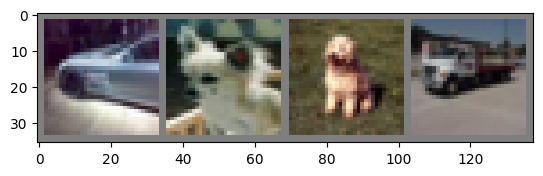

In [ ]:
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))


In [ ]:
from torchvision.transforms.transforms import ToPILImage
from torchvision import transforms

# Hyper-parameters
num_epochs = 2
learning_rate = 0.001

#Teacher model
model=torchvision.models.resnet18(pretrained=True)
num_ftrs=model.fc.in_features
model.fc=nn.Linear(num_ftrs, 10)
bmodel = model.to(device)
# print(bmodel)
criterionA = nn.CrossEntropyLoss()
optimizerA = torch.optim.SGD(bmodel.parameters(), lr=learning_rate)
n_total_steps = len(train_loader)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 165MB/s]


In [ ]:
def train_model(train_loader, optimizer, model, criterion, num_epochs, model_name):
    for epoch in range(num_epochs):
        for i, (images, labels) in enumerate(train_loader):
            # origin shape: [4, 3, 32, 32] = 4, 3, 1024
            # input_layer: 3 input channels, 6 output channels, 5 kernel size
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if (i+1) % 2000 == 0:
                print (f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{n_total_steps}], Loss: {loss.item():.4f}')

    print('Finished Training')
    PATH = './'+ model_name
    torch.save(model.state_dict(), PATH)

In [ ]:
num_epochs=2
train_model(train_loader=train_loader, model=bmodel, criterion=criterionA,
            num_epochs=num_epochs, optimizer=optimizerA, model_name="full_cnn.pth")

Epoch [1/2], Step [2000/12500], Loss: 1.4705
Epoch [1/2], Step [4000/12500], Loss: 1.6163
Epoch [1/2], Step [6000/12500], Loss: 1.0431
Epoch [1/2], Step [8000/12500], Loss: 1.1105
Epoch [1/2], Step [10000/12500], Loss: 1.4006
Epoch [1/2], Step [12000/12500], Loss: 0.9761
Epoch [2/2], Step [2000/12500], Loss: 1.5031
Epoch [2/2], Step [4000/12500], Loss: 1.6879
Epoch [2/2], Step [6000/12500], Loss: 2.0594
Epoch [2/2], Step [8000/12500], Loss: 1.3322
Epoch [2/2], Step [10000/12500], Loss: 1.0519
Epoch [2/2], Step [12000/12500], Loss: 0.5151
Finished Training


In [ ]:
bmodel.eval()

with torch.no_grad():
    n_correct = 0
    n_samples = 0
    n_class_correct = [0 for i in range(10)]
    n_class_samples = [0 for i in range(10)]
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = bmodel(images)
        # max returns (value ,index)
        _, predicted = torch.max(outputs, 1)
        n_samples += labels.size(0)
        n_correct += (predicted == labels).sum().item()

        for i in range(batch_size):
            label = labels[i]
            pred = predicted[i]
            if (label == pred):
                n_class_correct[label] += 1
            n_class_samples[label] += 1

    acc = 100.0 * n_correct / n_samples
    print(f'Accuracy of the network: {acc} %')

    for i in range(10):
        acc = 100.0 * n_class_correct[i] / n_class_samples[i]
        print(f'Accuracy of {classes[i]}: {acc} %')

Accuracy of the network: 69.02 %
Accuracy of plane: 69.3 %
Accuracy of car: 78.7 %
Accuracy of bird: 49.8 %
Accuracy of cat: 49.2 %
Accuracy of deer: 67.0 %
Accuracy of dog: 60.6 %
Accuracy of frog: 87.0 %
Accuracy of horse: 71.9 %
Accuracy of ship: 82.6 %
Accuracy of truck: 74.1 %


In [ ]:
list(bmodel.children())[0]

Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)

In [ ]:
# coding='utf-8'
"""t-SNE对手写数字进行可视化"""
from time import time
import numpy as np
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.manifold import TSNE


X = test_dataset.data
X = np.array([x_i.flatten() for x_i in X])
X = X / 255 # normalize
y = test_dataset.targets

In [ ]:
X_embedded = TSNE(n_components=2, perplexity=50).fit_transform(X[:5000])

In [ ]:
X_embedded.shape

(5000, 2)

In [ ]:
colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k', 'w', 'orange', 'purple']
c = [colors[y_i] for y_i in y[:5000]]

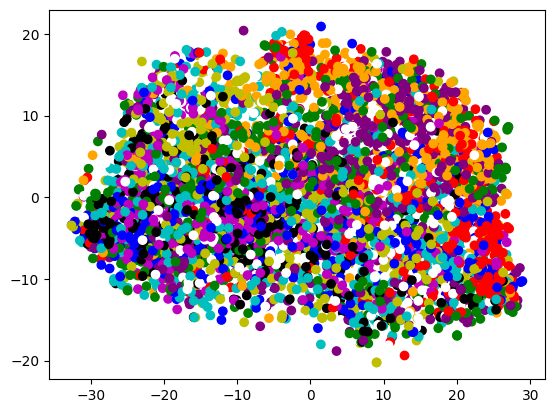

In [ ]:
plt.scatter(X_embedded[:,0], X_embedded[:,1], c=c)